In [7]:
import numpy as np
from qiskit.quantum_info import Statevector as sv

In [2]:
prob1 = np.array([0.4,0.6])
prob2 = np.array([0.3,0.7])
tensor = np.kron(prob1,prob2)

vec1 = np.sqrt(prob1)
vec2 = np.sqrt(prob2)
tensor_vec = np.kron(vec1,vec2)
np.linalg.norm(tensor_vec)


np.float64(1.0)

In [3]:
statevec = sv(vec1)
print(statevec)

Statevector([0.63245553+0.j, 0.77459667+0.j],
            dims=(2,))


In [4]:
vec = -1j * np.ones(8)
vec /= np.linalg.norm(vec)
statevector = sv(vec)
statevector

Statevector([0.-0.35355339j, 0.-0.35355339j, 0.-0.35355339j,
             0.-0.35355339j, 0.-0.35355339j, 0.-0.35355339j,
             0.-0.35355339j, 0.-0.35355339j],
            dims=(2, 2, 2))


In [5]:
statevector.probabilities

<bound method Statevector.probabilities of Statevector([0.-0.35355339j, 0.-0.35355339j, 0.-0.35355339j,
             0.-0.35355339j, 0.-0.35355339j, 0.-0.35355339j,
             0.-0.35355339j, 0.-0.35355339j],
            dims=(2, 2, 2))>

In [6]:
statevector.probabilities_dict()

{np.str_('000'): np.float64(0.12499999999999997),
 np.str_('001'): np.float64(0.12499999999999997),
 np.str_('010'): np.float64(0.12499999999999997),
 np.str_('011'): np.float64(0.12499999999999997),
 np.str_('100'): np.float64(0.12499999999999997),
 np.str_('101'): np.float64(0.12499999999999997),
 np.str_('110'): np.float64(0.12499999999999997),
 np.str_('111'): np.float64(0.12499999999999997)}

In [7]:
statevector.sample_counts(1000)

{np.str_('000'): np.int64(128),
 np.str_('001'): np.int64(124),
 np.str_('010'): np.int64(120),
 np.str_('011'): np.int64(111),
 np.str_('100'): np.int64(135),
 np.str_('101'): np.int64(125),
 np.str_('110'): np.int64(111),
 np.str_('111'): np.int64(146)}

In [8]:
vec = sv.from_label("0")
vec

Statevector([1.+0.j, 0.+0.j],
            dims=(2,))


In [9]:
from qiskit.circuit.library import XGate, RXGate, RYGate, RZGate

gate = RXGate(0.5)
mat = np.array(gate)
mat

array([[0.96891242+0.j        , 0.        -0.24740396j],
       [0.        -0.24740396j, 0.96891242+0.j        ]])

In [10]:
mat @ mat.T.conj()

array([[1.+0.j, 0.+0.j],
       [0.+0.j, 1.+0.j]])

In [11]:
vec = sv.from_label("0")
vec = vec.evolve(XGate())
vec.sample_counts(1000)

{np.str_('1'): np.int64(1000)}

$$\ket{\psi} = \alpha \ket{0} + \beta \ket{1}$$
$$\lvert \alpha \rvert^2 + \lvert \beta \rvert^2 = 1$$
$$\ket{\psi} = \cos \frac{\theta}{2} \ket{0} 

In [12]:
import cmath
import math

def bloch_angles(a: complex, b: complex) -> tuple[float, float]:
    global_phase = cmath.rect(1, cmath.phase(a))
    a *= global_phase.conjugate()
    b *= global_phase.conjugate()
    assert math.isclose(a.imag, 0)
    return 2*math.acos(a.real), cmath.phase(b)

In [13]:
vec = sv.from_label("0")
vec

print(bloch_angles(*vec))

(0.0, 0.0)


In [14]:

vec = vec.evolve(RXGate(np.pi/2))
vec = vec.evolve(RYGate(np.pi/2))
#vec = vec.evolve(RZGate(np.pi/2))
print(bloch_angles(*vec))
vec.sample_counts(1000)

(1.5707963267948961, -1.5707963267948966)


{np.str_('0'): np.int64(482), np.str_('1'): np.int64(518)}

1.5707963267948961 -1.5707963267948966


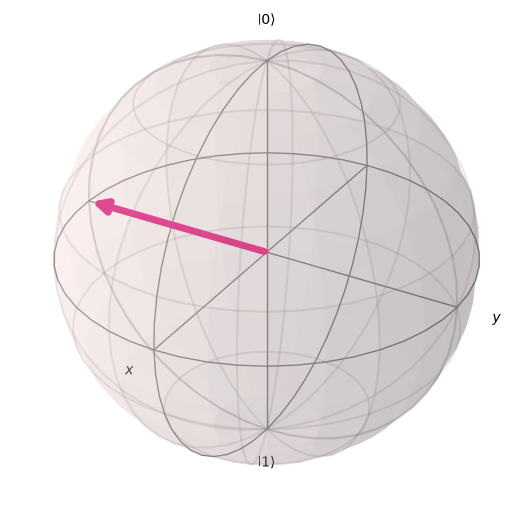

In [15]:
from qiskit.visualization import plot_bloch_vector

theta, phi = bloch_angles(*vec)
print(theta, phi)

plot_bloch_vector([1, theta, phi], coord_type="spherical")

In [6]:
from qiskit import QuantumCircuit
from qiskit_aer.library import save_statevector
from qiskit.visualization import plot_histogram as ph
from qiskit.visualization import plot_bloch_multivector
import matplotlib.pyplot as plt
from matplotlib.pyplot import Figure
qc1 = QuantumCircuit(2)
qc1.x(0)
qc1.cx(0,1)
qc1.cx(1,0)
qc1.cx(0,1)

qc1.save_statevector()


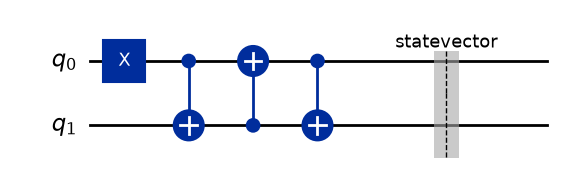

In [17]:
qc1.draw("mpl")

In [18]:
qc2 = QuantumCircuit(2)
qc2.x(0)
qc2.swap(0,1)

qc2.save_statevector()

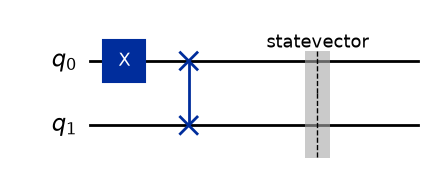

In [19]:
qc2.draw("mpl")

In [20]:
from qiskit_aer import AerSimulator
simulator = AerSimulator(method='statevector')

result_1 = simulator.run(qc1).result()
result_2 = simulator.run(qc2).result()

In [21]:
result_1.get_statevector() == result_2.get_statevector()

True

# Creating entanglement: Bell State

In [22]:
qc_ent = QuantumCircuit(2)
qc_ent.h(0)
qc_ent.cx(0,1)
qc_ent.measure_all()

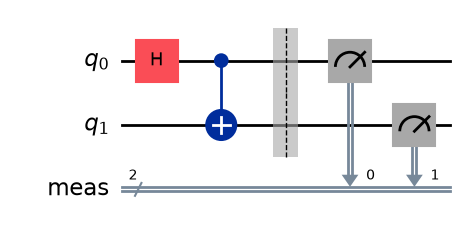

In [23]:
qc_ent.draw("mpl")

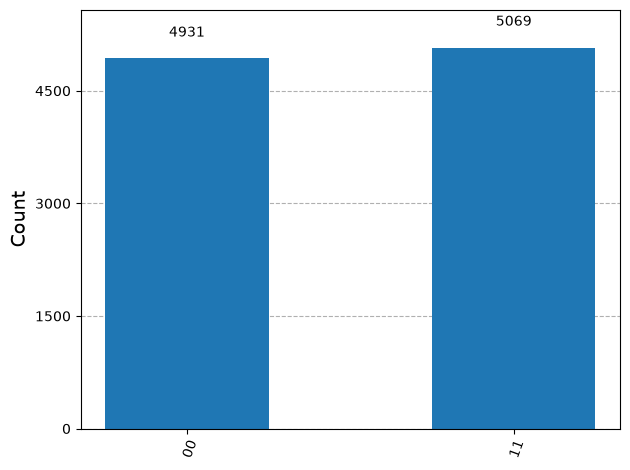

In [24]:
job = simulator.run(qc_ent, shots=10000)

result_ent = job.result()
counts = result_ent.get_counts()

ph(counts)

C:\Users\saikat\AppData\Local\Temp\ipykernel_29908\4075873557.py:15: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig1.show()
C:\Users\saikat\AppData\Local\Temp\ipykernel_29908\4075873557.py:18: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig2.show()


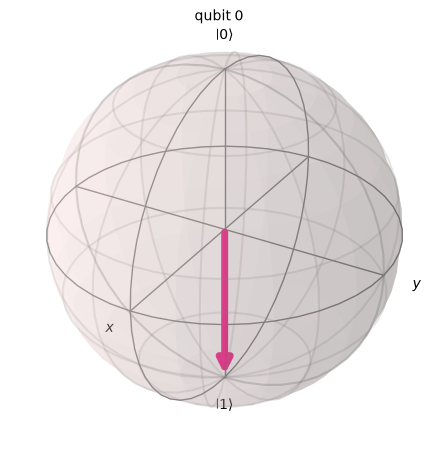

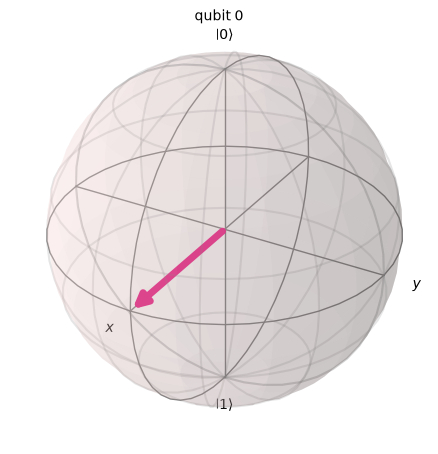

In [25]:
%matplotlib inline

qc_ref=QuantumCircuit(1)
qc_ref.h(0)
qc_ref.ry(np.pi/2,0)
qc_ref.save_statevector()
state = simulator.run(qc_ref).result().get_statevector()

qc_ref2 = QuantumCircuit(1)
qc_ref2.h(0)
qc_ref2.save_statevector()
state2 = simulator.run(qc_ref2).result().get_statevector()

fig1 = plot_bloch_multivector(state)
fig1.show()

fig2 = plot_bloch_multivector(state2)
fig2.show()

In [3]:
from qiskit_ibm_runtime import QiskitRuntimeService

QiskitRuntimeService.save_account(
    channel="ibm_quantum_platform",
    token="b1tmMEruSdXs4FQ1dGnZ122gxzaIN-pVvYYEP4OzJX3T",
    overwrite=True,
    set_as_default=True,
)

service = QiskitRuntimeService(channel='ibm_quantum_platform')

service = QiskitRuntimeService()

qiskit_runtime_service.__init__:WARNING:2026-07-18 08:56:37,245: Instance was not set at service instantiation. Free and trial plan instances will be prioritized. Based on the following filters: (tags: None, region: us-east, eu-de), and available plans: (open), the available account instances are: open-instance. If you need a specific instance set it explicitly either by using a saved account with a saved default instance or passing it in directly to QiskitRuntimeService().
qiskit_runtime_service.__init__:WARNING:2026-07-18 08:56:39,761: Instance was not set at service instantiation. Free and trial plan instances will be prioritized. Based on the following filters: (tags: None, region: us-east, eu-de), and available plans: (open), the available account instances are: open-instance. If you need a specific instance set it explicitly either by using a saved account with a saved default instance or passing it in directly to QiskitRuntimeService().


In [28]:
backend = service.least_busy(operational=True, simulator=False, min_num_qubits=127)
print(backend.name)

qiskit_runtime_service.backends:WARNING:2026-07-15 20:20:08,167: Loading instance: open-instance, plan: open
qiskit_runtime_service.backends:WARNING:2026-07-15 20:20:12,594: Using instance: open-instance, plan: open


ibm_fez


qiskit_runtime_service.backends:WARNING:2026-07-15 20:21:02,479: Using instance: open-instance, plan: open


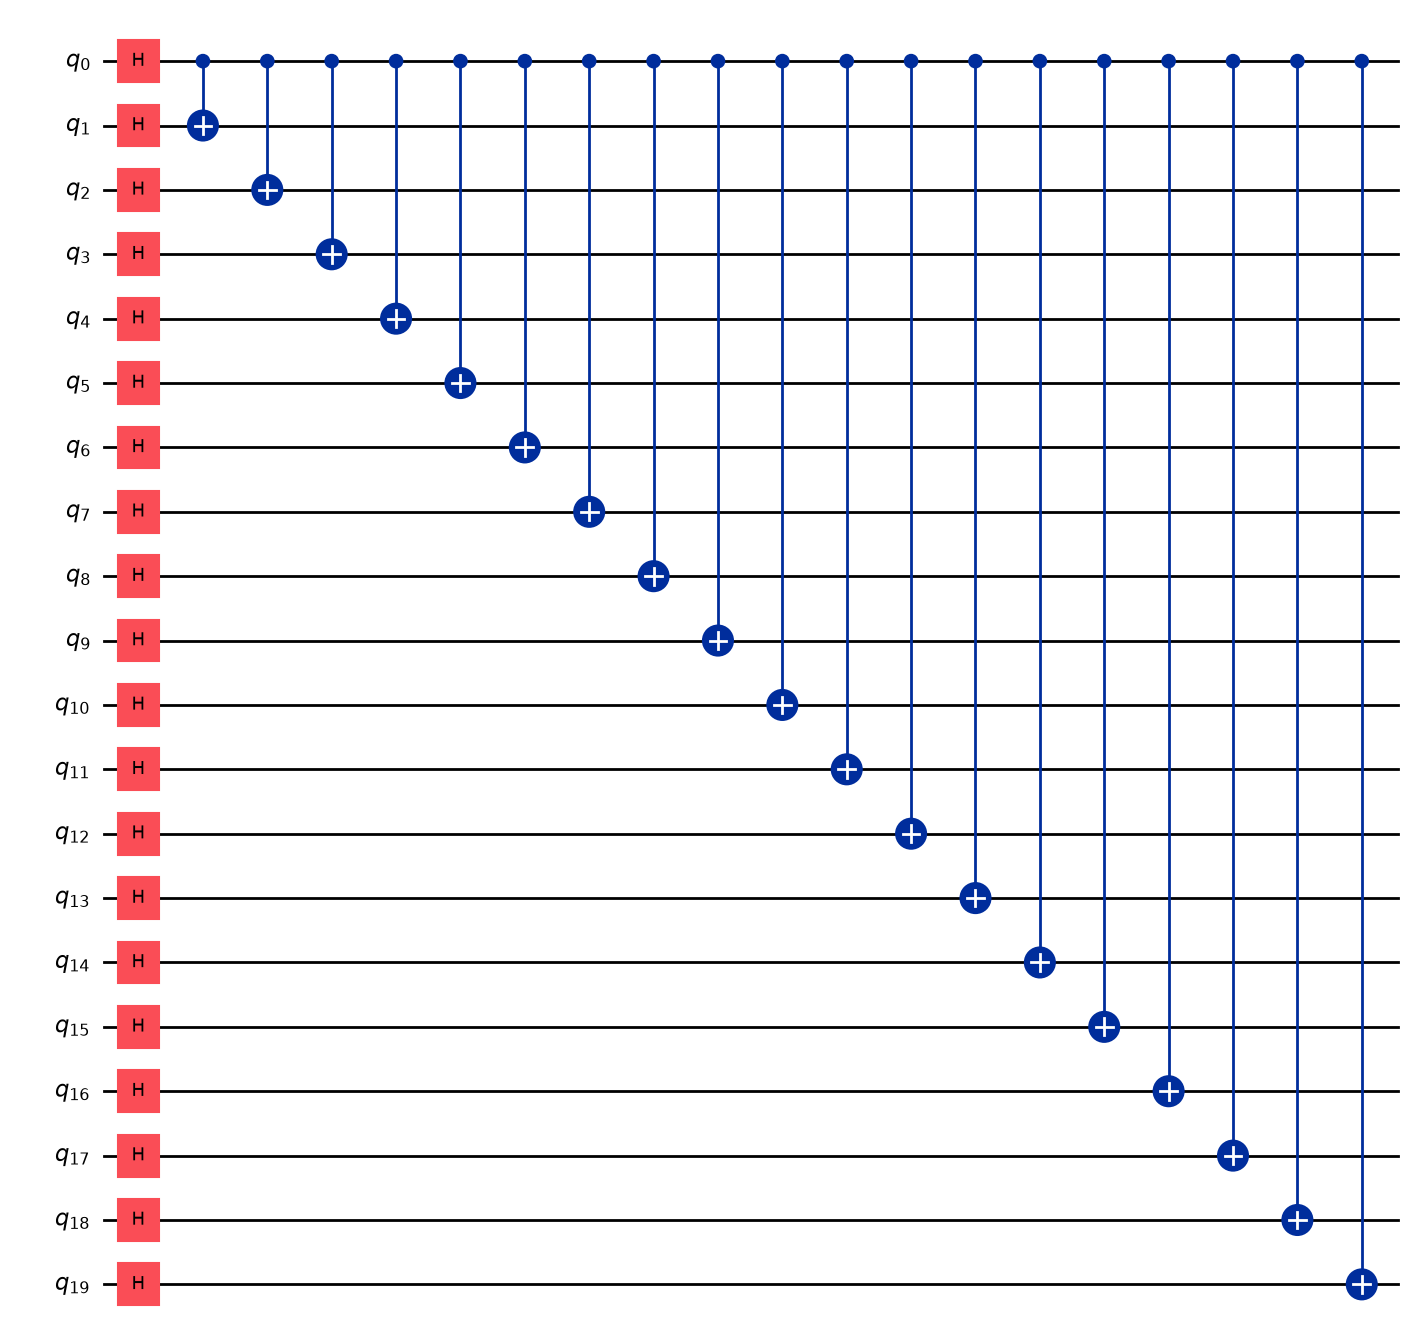

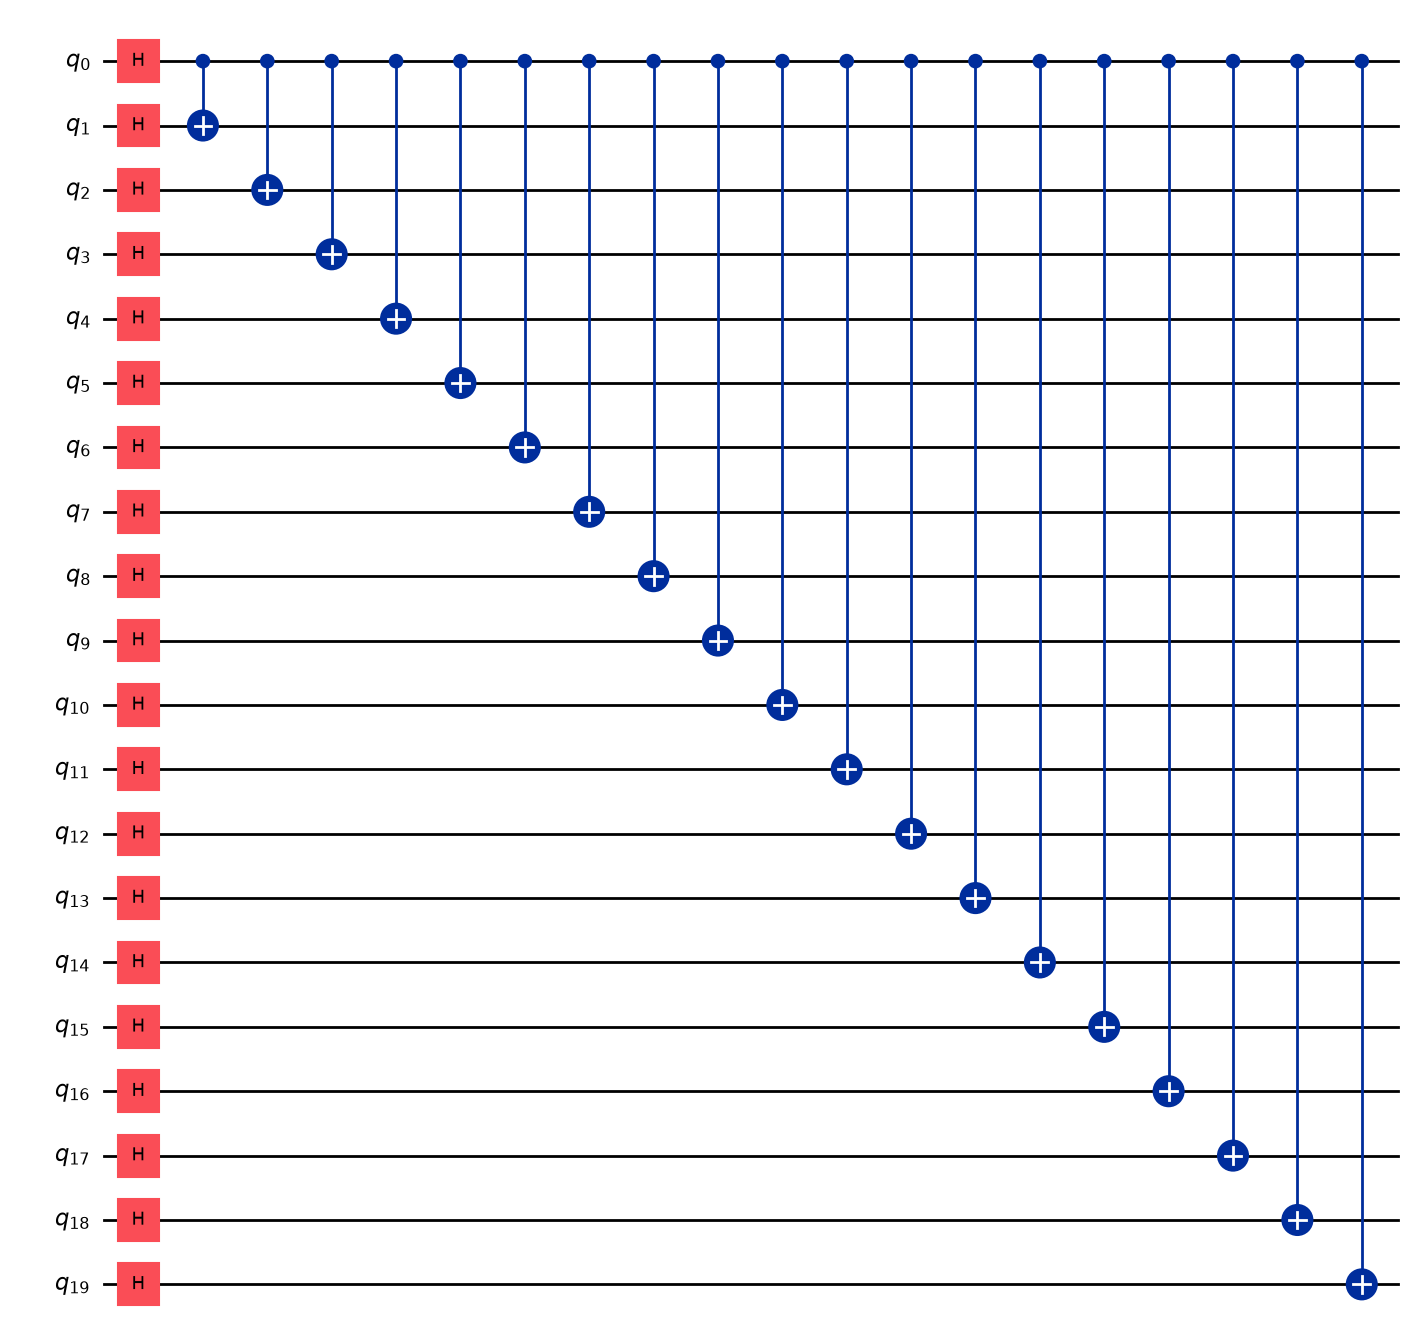

In [31]:
from qiskit.transpiler import generate_preset_pass_manager
backend = service.backend('ibm_fez')

pm = generate_preset_pass_manager(backend=backend, optimization_level=3)

qc = QuantumCircuit(20)
qc.h(range(20))

for i in range(1,20):
    qc.cx(0,i)

qc.draw("mpl")

In [32]:
xp_qc = pm.run(qc)

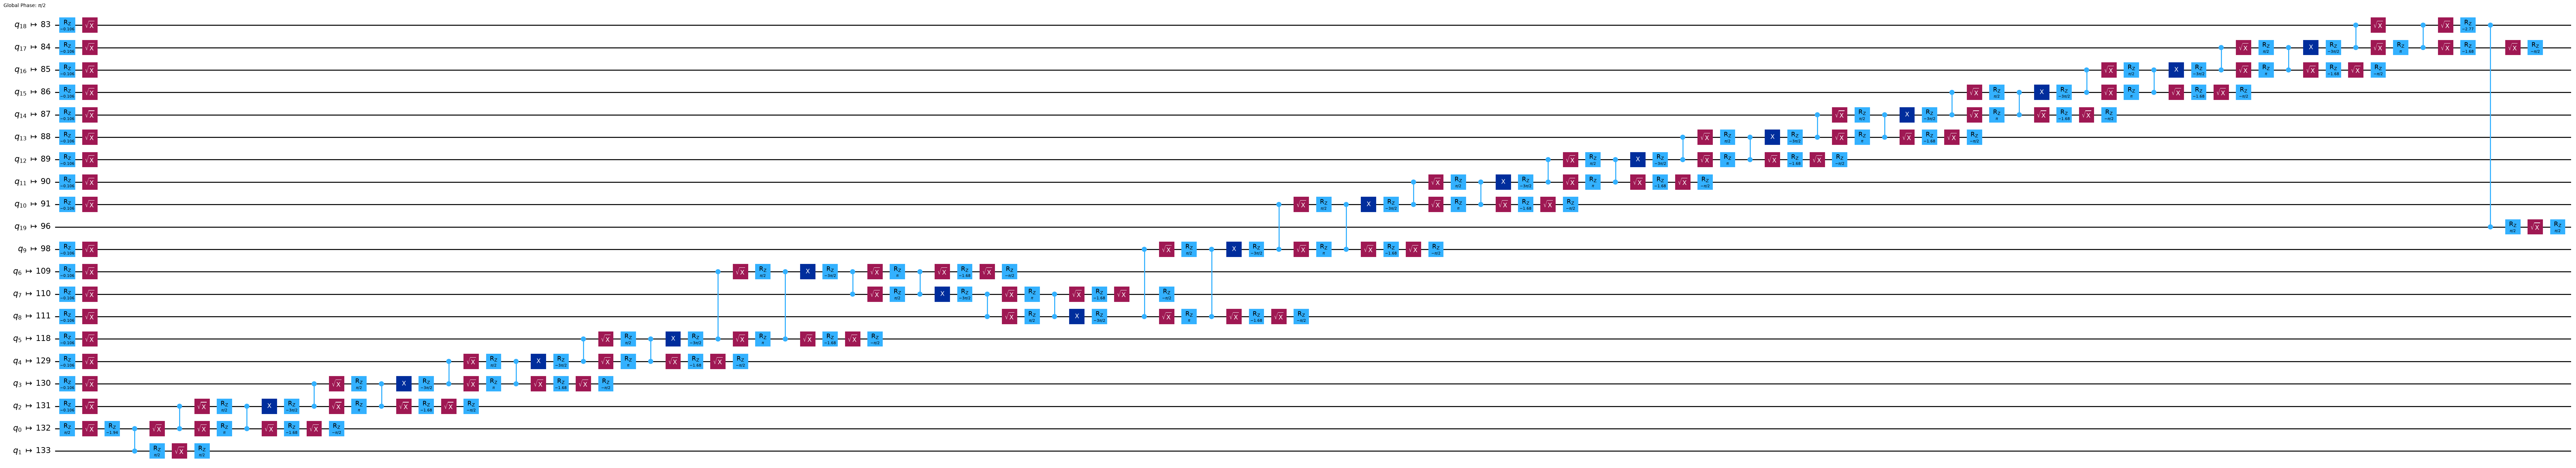

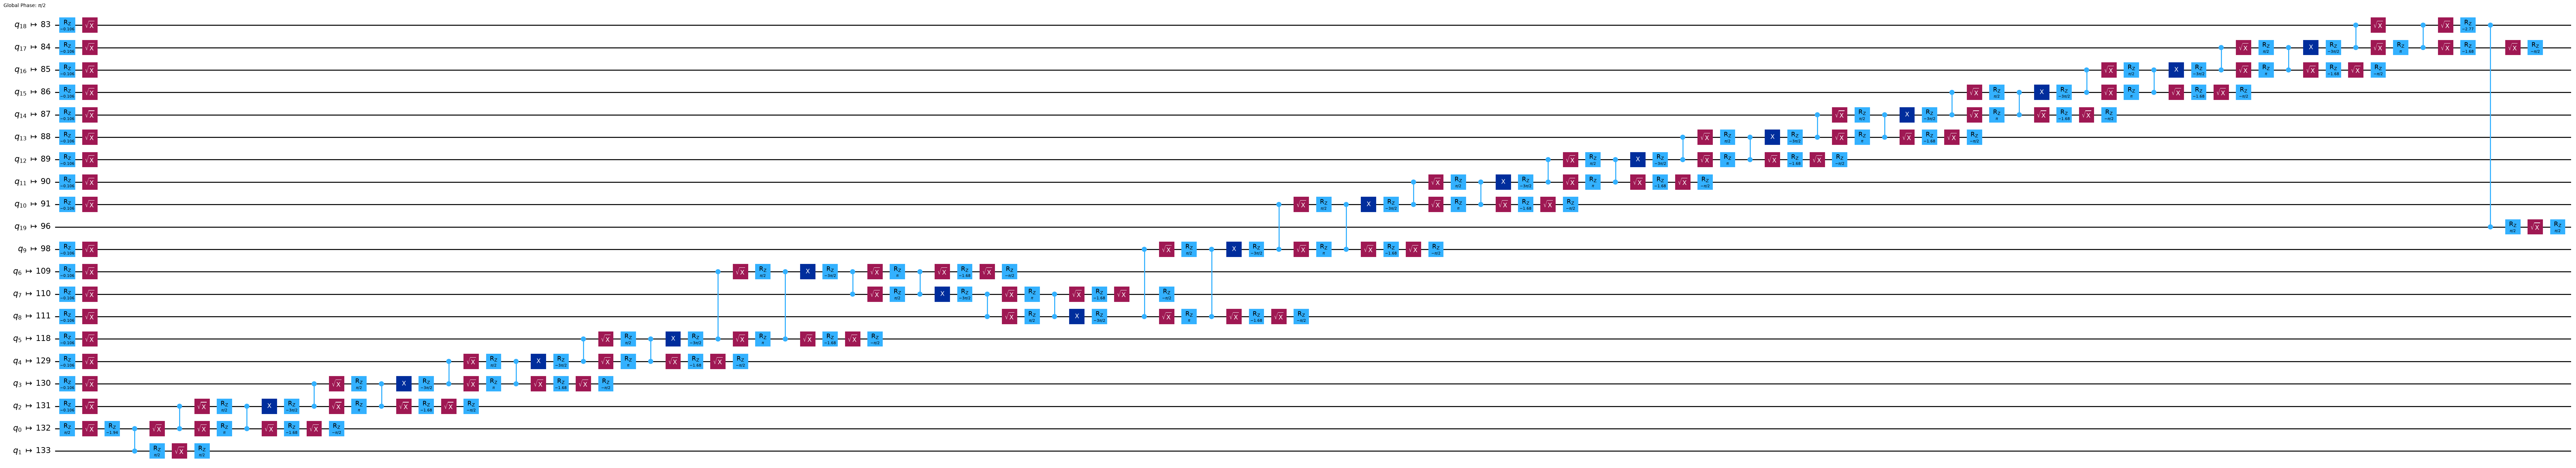

In [33]:
xp_qc.draw("mpl",fold=-1, idle_wires=False)

In [1]:
from qiskit.circuit.library import XXPlusYYGate
from qiskit.transpiler.preset_passmanagers import generate_preset_pass_manager
from qiskit_experiments.library import InterleavedRB

In [4]:
backend = service.least_busy(min_num_qubits=2)
physical_qubits = (0,1)
print(backend)

qiskit_runtime_service.backends:WARNING:2026-07-18 08:56:55,088: Using instance: open-instance, plan: open


<IBMBackend('ibm_marrakesh')>


In [10]:
import numpy as np

from qiskit import QuantumCircuit
from qiskit.circuit.library import XXPlusYYGate
from qiskit.quantum_info import Operator, Clifford
from qiskit_experiments.library import InterleavedRB
from IPython.display import display


# Define the intended two-qubit operation
qc = QuantumCircuit(2)
qc.append(
    XXPlusYYGate(theta=np.pi, beta=0.0),
    [0, 1]
)

# Convert the complete unitary into one Clifford object
iswap_dagger_clifford = Clifford.from_operator(Operator(qc))

print(iswap_dagger_clifford)

# Run interleaved randomized benchmarking
irb = InterleavedRB(
    interleaved_element=iswap_dagger_clifford,
    physical_qubits=physical_qubits,
    lengths=[1, 5, 10, 20, 50],
    backend=backend,
    num_samples=20,
    seed=42,
)

exp_data = irb.run().block_for_results()

display(exp_data.figure(0))
display(exp_data.analysis_results(dataframe=True))

Clifford: Stabilizer = ['+ZI', '+IZ'], Destabilizer = ['-YZ', '-ZY']


Job was cancelled before completion [Job ID: d9dfa0kjeosc73fhg640]


ExperimentEntryNotFound: 'Figure index 0 out of range.'

In [9]:
irb = InterleavedRB(
    interleaved_element=transpiled_gate,
    physical_qubits=physical_qubits,
    lengths=[1,5,10,20,50],
    backend=backend,
    num_samples=20,
    seed=42,
)
exp_data = irb.run().block_for_results()

display(exp_data.figure(0))
display(exp_data.analysis_results(dataframe=True))

QiskitError: 'Interleaved element circuit-149 could not be converted to Clifford.'

In [11]:
recent_jobs = service.jobs(
    backend_name=backend.name,
    limit=5,
)

for job in recent_jobs:
    print("\nJob:", job.job_id())
    print("Status:", job.status())

    try:
        print("Usage estimate:", job.usage_estimation)
    except Exception as exc:
        print("Usage unavailable:", exc)

    try:
        print("Metrics:", job.metrics())
    except Exception:
        pass


Job: d9dfa0kjeosc73fhg640
Status: CANCELLED
Usage estimate: {'quantum_seconds': None}
Metrics: {'caller': 'qiskit_experiments~framework~base_experiment.py', 'qiskit_version': 'qiskit_ibm_runtime-0.47.0,qiskit-2.4.0rc2*,qiskit_aer-0.17.2,qiskit_experiments-0.14.1*', 'timestamps': {'created': '2026-07-18T03:37:38.567271Z', 'finished': '2026-07-18T03:39:45.295807Z', 'running': '2026-07-18T03:37:39.261673Z'}, 'bss': {'seconds': 112}, 'usage': {'quantum_seconds': 0, 'seconds': 0, 'status': 'pending'}}

Job: d9a75uqf47jc73a9sh7g
Status: DONE
Usage estimate: {'quantum_seconds': None}
Metrics: {'caller': 'qiskit_ibm_runtime~sampler.py', 'qiskit_version': 'qiskit_ibm_runtime-0.47.0,qiskit-2.5.0*,qiskit_aer-0.17.2,qiskit_addon_opt_mapper-0.1.0,qiskit_addon_pna-0.2.0,qiskit_addon_slc-0.1.0,qiskit_addon_sqd-0.12.1,qiskit_addon_utils-0.3.1,mthree-3.0.0,pauli_prop-0.1.0', 'timestamps': {'created': '2026-07-13T05:09:15.734331Z', 'finished': '2026-07-13T05:09:36.980826Z', 'running': '2026-07-13T05:09

In [12]:
usage = service.usage()
print(usage)

{'instance_id': 'crn:v1:bluemix:public:quantum-computing:us-east:a/791b5db530a4411791529ab596a58671:6c39770d-8c08-427e-9b32-378a6080a594::', 'plan_id': '850b21a7-71de-4e53-9441-1abdd202f35d', 'usage_consumed_seconds': 118, 'usage_period': {'start_time': '2026-06-20T03:45:29.592Z', 'end_time': '2026-07-18T03:45:29.592Z'}, 'usage_limit_seconds': 600, 'usage_limit_reached': False, 'usage_remaining_seconds': 482}


In [13]:
usage = service.usage()

print("Window:", usage["usage_period"])
print("Consumed:", usage["usage_consumed_seconds"])
print("Remaining:", usage["usage_remaining_seconds"])
print("Available at:", usage.get("time_available_at"))

Window: {'start_time': '2026-06-20T03:48:17.550Z', 'end_time': '2026-07-18T03:48:17.550Z'}
Consumed: 118
Remaining: 482
Available at: None
